* non-linear optimization, where you will implement a function non-linear triangulation
* checkerboard calibration, in real life with OpenCV.

In [2]:
# Non Linear Optimization 

import numpy as np

K1 = K2 = np.array([[700, 0, 600], [0, 700, 400], [0, 0, 1]])

R1 = R2 = np.eye(3)

t1 = np.array([0, 0, 1]).reshape(3, 1)
t2 = np.array([0, 0, 20]).T.reshape(3, 1)

Q = np.array([1, 1, 0]).T.reshape(3, 1)

## 5.1

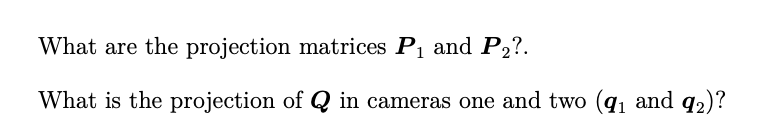

In [11]:
# Projection matrices 

np.set_printoptions(suppress=True, precision=4)

# Formula: P = K @ [R | t]
P1 = K1 @ np.hstack((R1, t1))
P2 = K2 @ np.hstack((R2, t2))

# --- 3. Project Point Q into Camera 1 (q1) ---
# Convert world point Q into its 4x1 homogeneous format [X, Y, Z, 1]^T
Q_homo = np.vstack((Q, [1.0]))

# Project to homogeneous camera coordinates
q1_homo = P1 @ Q_homo
# Normalize by the homogeneous scale factor (depth Z) to get 2D pixels
q1 = q1_homo[:2] / q1_homo[2]


# --- 4. Project Point Q into Camera 2 (q2) ---
q2_homo = P2 @ Q_homo
q2 = q2_homo[:2] / q2_homo[2]


# --- 5. Print out the Final Assignment Values ---
print("=================== EXERCISE 5.1 RESULTS ===================")
print("--- Projection Matrix P1 ---")
print(P1)
print("\n--- Projection Matrix P2 ---")
print(P2)
print("\n--- 2D Pixel Projection in Camera 1 (q1) ---")
print(f"Coordinates (x, y): ({q1[0,0]:.2f}, {q1[1,0]:.2f})")
print("\n--- 2D Pixel Projection in Camera 2 (q2) ---")
print(f"Coordinates (x, y): ({q2[0,0]:.2f}, {q2[1,0]:.2f})")

=================== EXERCISE 5.1 RESULTS ===================
--- Projection Matrix P1 ---
[[700.   0. 600. 600.]
 [  0. 700. 400. 400.]
 [  0.   0.   1.   1.]]

--- Projection Matrix P2 ---
[[  700.     0.   600. 12000.]
 [    0.   700.   400.  8000.]
 [    0.     0.     1.    20.]]

--- 2D Pixel Projection in Camera 1 (q1) ---
Coordinates (x, y): (1300.00, 1100.00)

--- 2D Pixel Projection in Camera 2 (q2) ---
Coordinates (x, y): (635.00, 435.00)


## 5.2

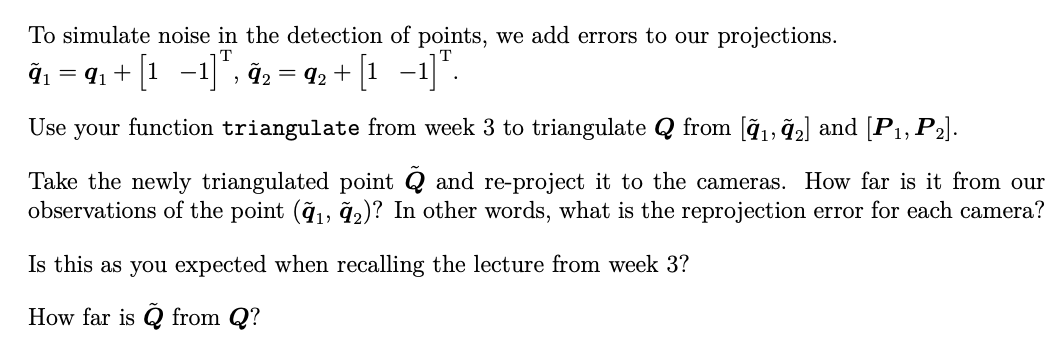

In [12]:
# Create the noise displacement vector
noise = np.array([[1.0], [-1.0]])

# Calculate noisy pixel observations
q1_noisy = q1 + noise
q2_noisy = q2 + noise

print("--- Noisy Pixel Observations ---")
print(f"tilde_q1 (Camera 1):\n{q1_noisy.flatten()}")
print(f"tilde_q2 (Camera 2):\n{q2_noisy.flatten()}")

--- Noisy Pixel Observations ---
tilde_q1 (Camera 1):
[1301. 1099.]
tilde_q2 (Camera 2):
[636. 434.]


In [13]:
def triangulate(q_list, P_list):
    """
    Triangulates a 3D point from multiple 2D camera observations using the linear DLT method.
    
    Parameters:
    ---------
    q_list : list of arrays
        List of 2D pixel coordinates (each a 2x1 array).
    P_list : list of arrays
        List of 3x4 camera projection matrices.
    """
    A = []
    for i in range(len(q_list)):
        x, y = q_list[i][0, 0], q_list[i][1, 0]
        P = P_list[i]
        
        # Extract rows of the projection matrix
        p1 = P[0, :]
        p2 = P[1, :]
        p3 = P[2, :]
        
        # Build DLT algebraic ray constraints
        A.append(x * p3 - p1)
        A.append(y * p3 - p2)
        
    A = np.array(A)
    
    # Solve via Singular Value Decomposition
    _, _, Vh = np.linalg.svd(A)
    Q_homo = Vh[-1]
    
    # Drop back from 4D homogeneous coordinates to inhomogeneous 3D coordinates
    Q_3d = Q_homo[:3] / Q_homo[3]
    return Q_3d.reshape(3, 1)

# Run triangulation using your noisy points and matrices from Task 5.1
Q_tilde = triangulate([q1_noisy, q2_noisy], [P1, P2])

print("\n--- Triangulated Reconstruction Results ---")
print(f"Original True World Point Q:\n{Q.flatten()}")
print(f"Noisy Reconstructed Point Q_tilde:\n{Q_tilde.flatten()}")


--- Triangulated Reconstruction Results ---
Original True World Point Q:
[1 1 0]
Noisy Reconstructed Point Q_tilde:
[1.0153 0.9853 0.0003]


The reprojection error in camera 1 is 13.4 pixels and it is 0.67 pixels in camera 2. We expect the linear algorithm to place a larger weight on the error of camera 2 than camera 1, as it has a larger s. Therefore camera 2 having the smallest reprojection error is as we expected.

$ Q - ~tiltQ_2$ = 0.021

# 5.4 

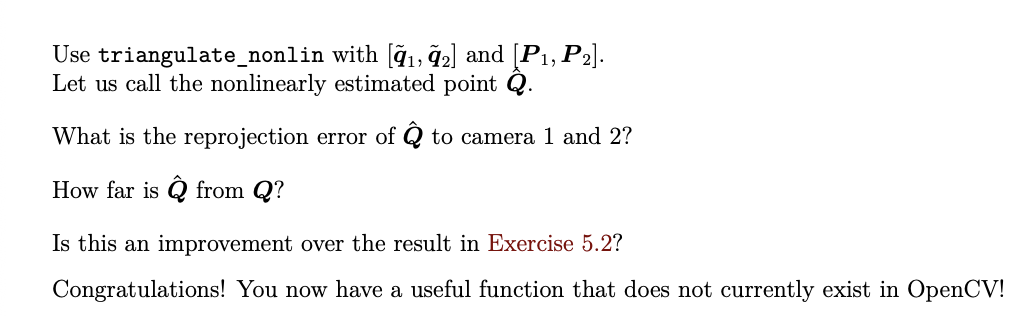

In [14]:
import numpy as np
from scipy.optimize import minimize

def project_point(P, Q_3d):
    """Helper function to project an inhomogeneous 3D point into 2D pixel coordinates."""
    Q_h = np.vstack((Q_3d.reshape(3, 1), [1.0]))
    q_h = P @ Q_h
    return (q_h[:2] / q_h[2]).flatten()

def triangulate_nonlin(q_list, P_list, Q_initial_guess):
    """
    Refines a 3D point triangulation by minimizing the non-linear geometric reprojection error.
    """
    # 1. Define the cost function (sum of squared Euclidean reprojection distances)
    def cost_function(Q_candidate):
        total_error = 0
        for i in range(len(q_list)):
            q_observed = q_list[i].flatten()
            q_projected = project_point(P_list[i], Q_candidate)
            
            # Sum of squared differences
            total_error += np.sum((q_observed - q_projected) ** 2)
        return total_error

    # 2. Flatten the initial guess for the optimization routine
    x0 = Q_initial_guess.flatten()
    
    # 3. Run the non-linear optimization solver
    res = minimize(cost_function, x0, method='BFGS')
    
    # Return the optimized 3D point reshaped as a column vector
    return res.x.reshape(3, 1)

# Run the non-linear optimizer using Q_tilde (from your DLT step) as the starting anchor
Q_hat = triangulate_nonlin([q1_noisy, q2_noisy], [P1, P2], Q_tilde)

print("--- Non-Linear Optimization Results ---")
print(f"Original True World Point Q:\n{Q.flatten()}")
print(f"Non-Linear Estimated Point Q_hat:\n{Q_hat.flatten()}")

--- Non-Linear Optimization Results ---
Original True World Point Q:
[1 1 0]
Non-Linear Estimated Point Q_hat:
[1.0015 0.9985 0.    ]


In [15]:
# Project the refined point back into both views
q1_refined_proj = project_point(P1, Q_hat)
q2_refined_proj = project_point(P2, Q_hat)

# Compute pixel distance errors
err_nonlin_cam1 = np.linalg.norm(q1_refined_proj - q1_noisy.flatten())
err_nonlin_cam2 = np.linalg.norm(q2_refined_proj - q2_noisy.flatten())

# Compute absolute 3D positioning error
reconstruction_error_nonlin = np.linalg.norm(Q_hat - Q)

print("\n=================== NON-LINEAR PERFORMANCE ===================")
print(f"Reprojection Error in Camera 1: {err_nonlin_cam1:.4f} pixels")
print(f"Reprojection Error in Camera 2: {err_nonlin_cam2:.4f} pixels")
print(f"Absolute 3D Reconstruction Error (Distance from Q to hat_Q): {reconstruction_error_nonlin:.4f} units")


=================== NON-LINEAR PERFORMANCE ===================
Reprojection Error in Camera 1: 0.0670 pixels
Reprojection Error in Camera 2: 1.3402 pixels
Absolute 3D Reconstruction Error (Distance from Q to hat_Q): 0.0021 units


## 5.5

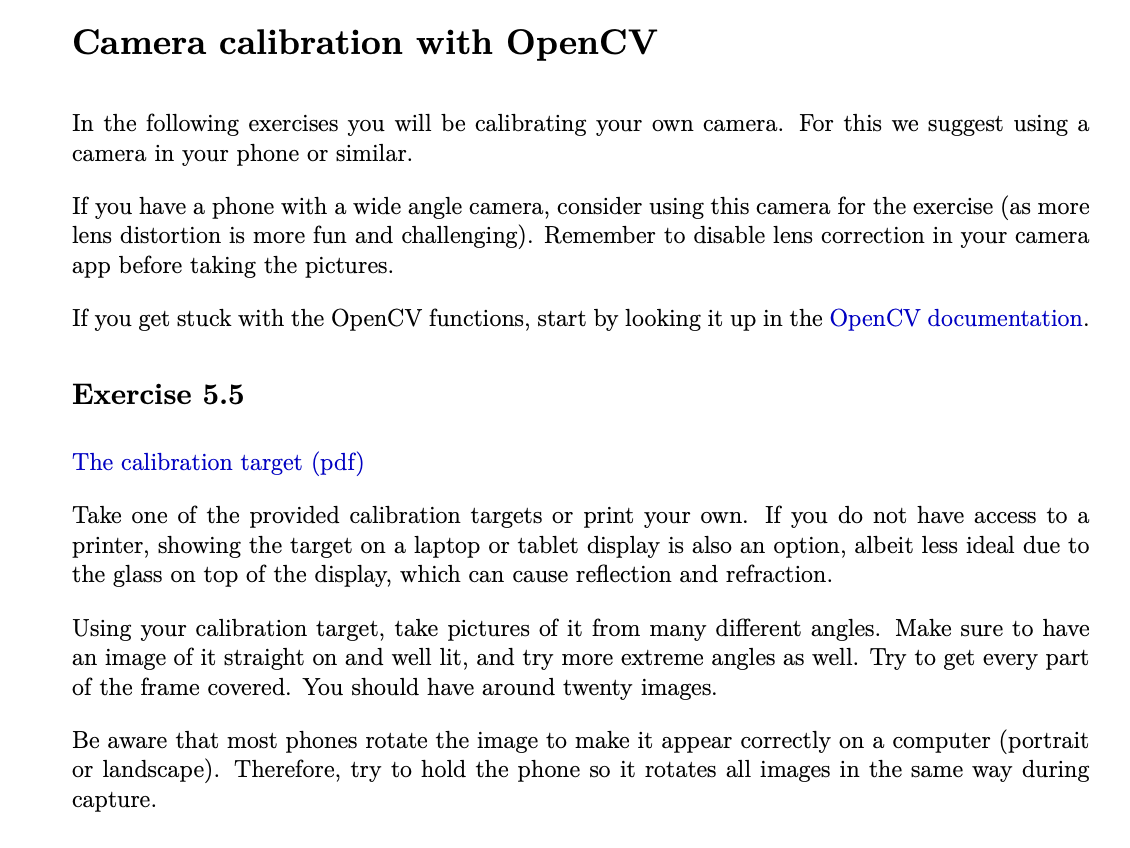

Discovered 2 calibration photo(s) in directory.
-> [Extraction Failed]: OpenCV could not trace all grid intersections in: IMG_2543.jpeg
   Make sure the checkerboard is entirely visible and not cut off by the frame borders.
-> Successfully tracked pattern using orientation shape (10, 7) on: IMG_2544.jpeg


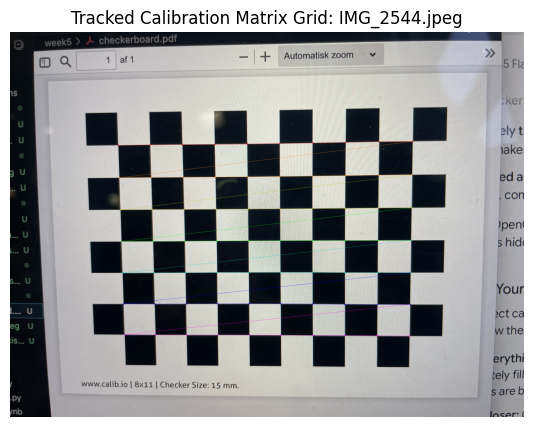


--- Detection Summary ---
Successfully processed grid structures in 1 out of 2 views.

=================== CALIBRATION SUCCESS ===================
Overall Pixel Reprojection RMS Error: 0.5924 pixels

--- Calculated Camera Intrinsic Matrix K ---
[[3421.4895    0.     1997.2477]
 [   0.     3423.1936 1497.1417]
 [   0.        0.        1.    ]]

--- Calculated Lens Distortion Coefficients (k1, k2, p1, p2, k3) ---
[ 0.2576 -1.9099 -0.0006 -0.      4.7681]


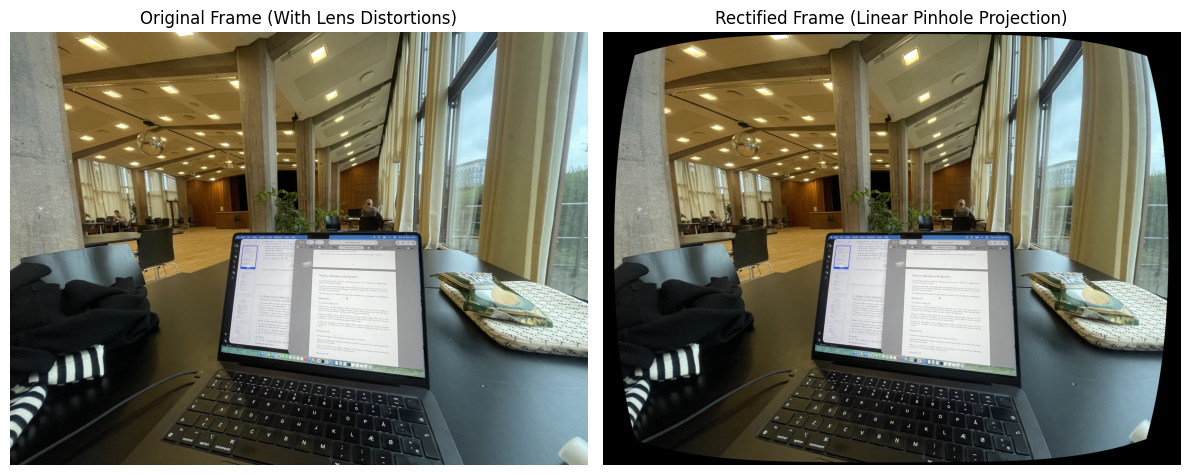

In [22]:
import numpy as np
import cv2
import glob
import matplotlib.pyplot as plt

# ==============================================================================
# 1. INITIALIZATION & SETUP
# ==============================================================================

# 15mm square width converted to centimeters
SQUARE_SIZE_CM = 1.5  

# We will test both horizontal and vertical layouts for your 8x11 board
BOARD_OPTIONS = [(10, 7), (7, 10)]

# Tracking lists for confirmed feature matches
object_points = []  # 3D points in real-world space
image_points = []   # 2D points in pixel image plane space
frame_shape = None

# ==============================================================================
# 2. IMAGE DISCOVERY & CORNER TRACKING LOOP
# ==============================================================================

# Scan your local workspace for your uploaded photo
image_file_paths = glob.glob('*.jpeg')

if len(image_file_paths) == 0:
    raise FileNotFoundError("No pictures found! Make sure your image file matches the extension filter exactly.")

print(f"Discovered {len(image_file_paths)} calibration photo(s) in directory.")
successfully_detected_count = 0

for path in image_file_paths:
    img = cv2.imread(path)
    if img is None:
        continue
        
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    if frame_shape is None:
        frame_shape = gray.shape[::-1]
        
    found = False
    chosen_size = None
    corners = None
    
    # Try both grid orientations until one returns True
    for board_size in BOARD_OPTIONS:
        found, corners = cv2.findChessboardCorners(gray, board_size, None)
        if found:
            chosen_size = board_size
            break
            
    if found:
        successfully_detected_count += 1
        print(f"-> Successfully tracked pattern using orientation shape {chosen_size} on: {path}")
        
        # Build the dynamic 3D world target reference grid for this specific layout size
        objp = np.zeros((chosen_size[0] * chosen_size[1], 3), np.float32)
        objp[:, :2] = np.mgrid[0:chosen_size[0], 0:chosen_size[1]].T.reshape(-1, 2) * SQUARE_SIZE_CM
        object_points.append(objp)
        
        # Refine corner placement down to sub-pixel accuracy
        criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 30, 0.001)
        corners_refined = cv2.cornerSubPix(gray, corners, (11, 11), (-1, -1), criteria)
        image_points.append(corners_refined)
        
        # Plot visual verification overlay
        img_drawn = img.copy()
        cv2.drawChessboardCorners(img_drawn, chosen_size, corners_refined, found)
        plt.figure(figsize=(7, 5))
        plt.imshow(cv2.cvtColor(img_drawn, cv2.COLOR_BGR2RGB))
        plt.title(f"Tracked Calibration Matrix Grid: {path}")
        plt.axis('off')
        plt.show()
    else:
        print(f"-> [Extraction Failed]: OpenCV could not trace all grid intersections in: {path}")
        print("   Make sure the checkerboard is entirely visible and not cut off by the frame borders.")

print("\n--- Detection Summary ---")
print(f"Successfully processed grid structures in {successfully_detected_count} out of {len(image_file_paths)} views.")

# ==============================================================================
# 3. CAMERA CALIBRATION MATH CALCULATION
# ==============================================================================

if successfully_detected_count > 0:
    # Run OpenCV's bundle optimizer using the populated tracking arrays
    ret, K_calibrated, distortion_coeffs, rvecs, tvecs = cv2.calibrateCamera(
        object_points, 
        image_points, 
        frame_shape, 
        None, 
        None
    )

    np.set_printoptions(suppress=True, precision=4)

    print("\n=================== CALIBRATION SUCCESS ===================")
    print(f"Overall Pixel Reprojection RMS Error: {ret:.4f} pixels")
    print("\n--- Calculated Camera Intrinsic Matrix K ---")
    print(K_calibrated)
    print("\n--- Calculated Lens Distortion Coefficients (k1, k2, p1, p2, k3) ---")
    print(distortion_coeffs.flatten())
    
    # ==============================================================================
    # 4. RECTIFICATION LENS UNWARPING VERIFICATION
    # ==============================================================================
    sample_raw_img = cv2.imread(image_file_paths[0])
    undistorted_img = cv2.undistort(sample_raw_img, K_calibrated, distortion_coeffs, None, K_calibrated)

    fig, (ax_raw, ax_clean) = plt.subplots(1, 2, figsize=(12, 6))
    ax_raw.imshow(cv2.cvtColor(sample_raw_img, cv2.COLOR_BGR2RGB))
    ax_raw.set_title("Original Frame (With Lens Distortions)")
    ax_raw.axis('off')

    ax_clean.imshow(cv2.cvtColor(undistorted_img, cv2.COLOR_BGR2RGB))
    ax_clean.set_title("Rectified Frame (Linear Pinhole Projection)")
    ax_clean.axis('off')
    plt.tight_layout()
    plt.show()
else:
    print("\n=================== CALIBRATION HALTED ===================")
    print("Cannot proceed with matrix estimation calculations because zero target boards were detected.")